# Lesson 22A: Bayesian Nonparametric Clustering — Dirichlet Process Mixtures (Theory)

## Introduction

Every clustering method so far in this course needs $K$ decided somewhere — swept by BIC (Lesson 4), pruned toward by a Dirichlet prior over a generously large but still FIXED upper bound (Lesson 21). This lesson removes the upper bound entirely. Instead of a prior over parameters for a fixed number of clusters, the Dirichlet process puts a prior directly over **partitions** of the data — and the number of clusters becomes something the data determines, not a hyperparameter to be searched.

The route here is deliberately indirect, because the indirection is the point. Three equivalent descriptions of the same object — the Chinese restaurant process (a sequential seating rule), stick-breaking (an infinite set of mixture weights), and the Dirichlet process itself (a distribution over probability measures) — describe the identical prior over partitions from three different angles, and Lesson 21's variational machinery already built the practical tool (a generous truncation plus a Dirichlet prior) that approximates the same object without needing all three descriptions. This lesson builds the exact, non-truncated version from scratch, so the approximation Lesson 21 already used can be measured against the thing it approximates.

In this lesson:
1. Why choosing $K$ is the wrong question, and what a prior over partitions looks like instead
2. The Chinese restaurant process: definition, exchangeability, rich-get-richer, and $\mathbb{E}[K_n] \approx \alpha\log n$ derived and simulated
3. Stick-breaking: the other construction of the same prior, and its equivalence to the CRP
4. The full DP mixture generative model, and why marginalising the infinite mixture weights recovers the CRP exactly
5. A from-scratch collapsed Gibbs sampler for a DP-GMM, with the label-switching caveat made concrete
6. The posterior over $K$ from the sampler's own trace, and its sensitivity to $\alpha$

## Table of Contents

1. [Introduction](#introduction)
2. [Required Libraries](#required-libraries)
3. [The Problem With Choosing K](#problem)
4. [The Chinese Restaurant Process](#crp)
5. [Stick-Breaking](#stick-breaking)
6. [The DP Mixture Model and the Blackwell-MacQueen Urn](#dp-mixture)
7. [Collapsed Gibbs Sampling for a DP-GMM](#gibbs)
8. [Posterior Over K and Sensitivity to Alpha](#posterior-k)
9. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 0
rng = np.random.default_rng(SEED)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Data: in-notebook synthetic 2D mixtures with unknown K -- nothing downloaded.")

Data: in-notebook synthetic 2D mixtures with unknown K -- nothing downloaded.


<a name="problem"></a>
## The Problem With Choosing K

Lesson 4 swept $K$ with BIC — a refit per candidate. Lesson 21 pruned a generously large, but still fixed, $K_{\max}$ down toward the "true" count with a Dirichlet prior. Both treat $K$ as a number to search for. A **prior over partitions** treats the assignment of points to clusters as the thing with a prior distribution directly — no $K$ is fixed in advance, and the number of occupied clusters after seeing $n$ points is a random variable with its own distribution, induced by the prior together with the data. The Chinese restaurant process, defined next, is the canonical such prior.

<a name="crp"></a>
## The Chinese Restaurant Process

**Definition.** Customers $1, 2, \dots$ arrive one at a time at a restaurant with infinitely many tables. Customer 1 sits at table 1. Having observed $i$ customers seated at $K$ occupied tables with counts $n_1,\dots,n_K$ ($\sum_k n_k = i$), customer $i+1$:

$$\text{sits at table } k \text{ with probability } \frac{n_k}{i + \alpha}, \qquad \text{sits at a NEW table with probability } \frac{\alpha}{i+\alpha}.$$

$\alpha > 0$ is the **concentration parameter**: larger $\alpha$ means new tables are chosen more often, hence more clusters.

**Rich-get-richer.** A table's probability of gaining the next customer is proportional to its current size $n_k$ — larger tables grow faster in absolute terms, though the *fraction* of customers at any one table does not simply keep increasing (new tables continually appear too).

**Exchangeability.** The probability of any particular seating arrangement (partition into tables) does not depend on the ORDER customers arrived in — only on the resulting group sizes. This is what licenses using the CRP as a prior over an unordered partition of i.i.d. data: relabelling which data point is "customer 1" must not change the prior probability of the resulting clustering, and exchangeability is exactly that invariance.

**Expected number of tables.** At step $i+1$, a new table is started with probability $\alpha/(i+\alpha)$ — a Bernoulli event, independent in the accumulating sense that its probability depends only on $i$, not on which tables exist. So

$$\mathbb{E}[K_n] = \sum_{i=0}^{n-1} \frac{\alpha}{i+\alpha} = \alpha\sum_{i=0}^{n-1}\frac{1}{i+\alpha} \;\approx\; \alpha\log n \quad (n\to\infty),$$

the sum behaving like $\alpha \ln n$ up to a constant, since $\sum_{i=0}^{n-1} 1/(i+\alpha)$ is a harmonic-series tail. Checked below both as the exact finite-$n$ sum against simulation, and as the large-$n$ log-growth.

E[K_200] with alpha=2.0: exact finite sum = 9.766, simulated mean over 500 runs = 10.056 (std 2.831)
large-n approximation alpha*log(n) = 10.597  (a coarser approximation than the exact sum, as expected)

exchangeability check, two different arrival sequences reaching the same block sizes {3,2}:
  log P(order 1) = -4.279267
  log P(order 2) = -4.279267
  match to 0.00e+00 (should be ~0 -- the CRP prior depends on the partition's block sizes, not the arrival path taken to reach them)


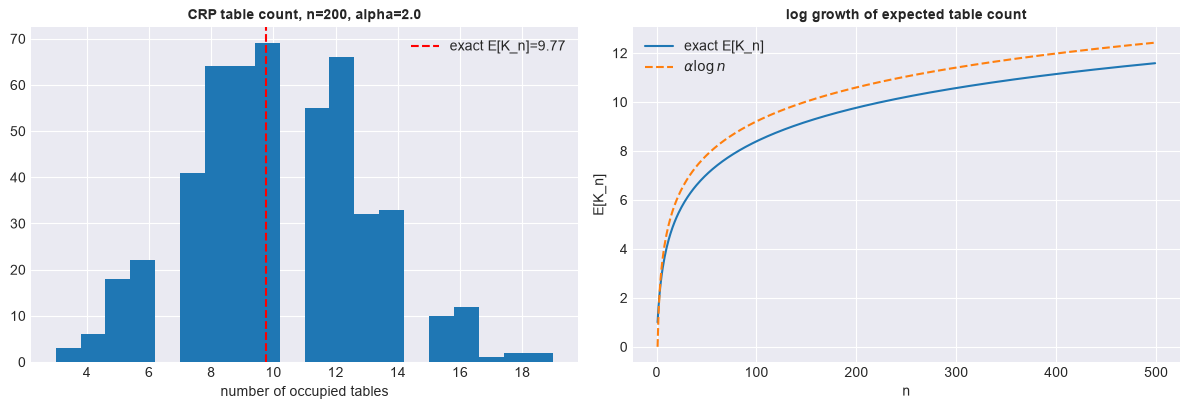

In [2]:
def simulate_crp(n, alpha, seed=0):
    rng_local = np.random.default_rng(seed)
    table_of = np.zeros(n, dtype=int)
    table_of[0] = 0
    counts = [1]
    for i in range(1, n):
        probs = np.array(counts + [alpha]) / (i + alpha)
        choice = rng_local.choice(len(probs), p=probs)
        if choice == len(counts):
            counts.append(1)
        else:
            counts[choice] += 1
        table_of[i] = choice
    return table_of, np.array(counts)


# Exact finite-n expectation vs simulation (averaged over many runs).
n, alpha = 200, 2.0
exact_EKn = sum(alpha / (i + alpha) for i in range(n))
n_runs = 500
sim_Kn = [len(simulate_crp(n, alpha, seed=s)[1]) for s in range(n_runs)]
print(f"E[K_{n}] with alpha={alpha}: exact finite sum = {exact_EKn:.3f}, "
      f"simulated mean over {n_runs} runs = {np.mean(sim_Kn):.3f} (std {np.std(sim_Kn):.3f})")
print(f"large-n approximation alpha*log(n) = {alpha * np.log(n):.3f}  "
      f"(a coarser approximation than the exact sum, as expected)")

# Exchangeability check: same customers, two different arrival orders, same partition
# (as an unordered set of groups) -- probability of that specific SEATING should match.
def seating_log_prob(order_of_table_assignments, alpha):
    # order_of_table_assignments: table index assigned to each customer IN ARRIVAL ORDER
    counts = []
    log_p = 0.0
    for i, t in enumerate(order_of_table_assignments):
        denom = i + alpha
        if t == len(counts):
            log_p += np.log(alpha / denom)
            counts.append(1)
        else:
            log_p += np.log(counts[t] / denom)
            counts[t] += 1
    return log_p


# seating_log_prob's argument is indexed by ARRIVAL POSITION, not customer label: entry i is
# the table the (i+1)-th customer TO ARRIVE sits at. order_1 and order_2 below are two DIFFERENT
# arrival sequences that both end with one table of size 3 and one of size 2 -- and the CRP's
# probability of a partition depends only on its block SIZES, never on chronological arrival
# detail or which customers ended up in which block. So this checks exactly that invariance:
# two sequences that build up to {3,2} by different paths (new table first vs. two new tables
# back-to-back before either grows) must get the identical probability, which is what
# exchangeability actually asserts -- not a claim about a specific permutation of 5 named people.
order_1 = [0, 0, 1, 0, 1]   # sizes encountered, in order: new(1), grows to 2, new(1), grows to 3, grows to 2
order_2 = [0, 1, 0, 0, 1]   # sizes encountered, in order: new(1), new(1), grows to 2, grows to 3, grows to 2
lp1 = seating_log_prob(order_1, alpha=1.5)
lp2 = seating_log_prob(order_2, alpha=1.5)
print(f"\nexchangeability check, two different arrival sequences reaching the same block sizes {{3,2}}:")
print(f"  log P(order 1) = {lp1:.6f}")
print(f"  log P(order 2) = {lp2:.6f}")
print(f"  match to {abs(lp1-lp2):.2e} (should be ~0 -- the CRP prior depends on the partition's block sizes, not the arrival path taken to reach them)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].hist(sim_Kn, bins=20)
axes[0].axvline(exact_EKn, color='red', ls='--', label=f'exact E[K_n]={exact_EKn:.2f}')
axes[0].set_xlabel('number of occupied tables'); axes[0].legend()
axes[0].set_title(f'CRP table count, n={n}, alpha={alpha}', fontweight='bold', fontsize=10)

ns = np.arange(1, 500)
exact_by_n = [sum(alpha / (i + alpha) for i in range(nn)) for nn in ns]
axes[1].plot(ns, exact_by_n, label='exact E[K_n]')
axes[1].plot(ns, alpha * np.log(ns), '--', label=r'$\alpha \log n$')
axes[1].set_xlabel('n'); axes[1].set_ylabel('E[K_n]'); axes[1].legend()
axes[1].set_title('log growth of expected table count', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

<a name="stick-breaking"></a>
## Stick-Breaking

A second construction of the same object. Draw an infinite sequence $\beta_1,\beta_2,\dots \overset{iid}{\sim} \mathrm{Beta}(1,\alpha)$, and set

$$\pi_k = \beta_k \prod_{j<k}(1-\beta_j),$$

"breaking off" a $\beta_k$ fraction of whatever stick remains after the first $k-1$ pieces. This produces an infinite sequence of weights with $\sum_k \pi_k = 1$ almost surely (each break takes a random fraction of an ever-shrinking remainder, and the remainder shrinks geometrically in expectation, at rate $\mathbb{E}[1-\beta_k] = \alpha/(1+\alpha)$).

**Equivalence to the CRP (Sethuraman, 1994).** Draw component parameters $\theta_k^\star \overset{iid}{\sim} G_0$ for $k=1,2,\dots$, then assign each data point $i$ to component $z_i$ with $P(z_i = k) = \pi_k$. The resulting distribution over how points GROUP TOGETHER (which points share the same $z_i$) is exactly the CRP's partition distribution with the same $\alpha$ — a full proof is a measure-theoretic argument beyond this lesson's scope, but the claim is checkable empirically: draw many samples from each construction and compare the resulting distribution over the number of distinct groups actually used.

stick-breaking truncated at K=300: mass left in the discarded tail = 0.00e+00 (negligible -- the truncation is a numerical convenience, not part of the claim being checked)



number of distinct clusters used, n=200, alpha=2.0, 500 runs each:
  stick-breaking: mean 9.802, std 2.670
  CRP:            mean 10.056, std 2.831
  difference in means: 0.254 (small relative to either std -- consistent with the claimed equivalence, not a proof of it)


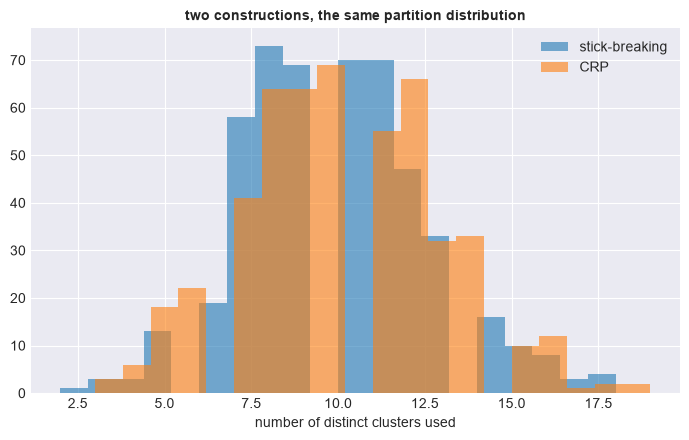

In [3]:
def stick_breaking_weights(alpha, K_trunc, seed=0):
    rng_local = np.random.default_rng(seed)
    betas = rng_local.beta(1, alpha, size=K_trunc)
    remaining = np.cumprod(1 - betas)
    pi = np.empty(K_trunc)
    pi[0] = betas[0]
    pi[1:] = betas[1:] * remaining[:-1]
    return pi


def simulate_stick_breaking_partition(n, alpha, K_trunc=200, seed=0):
    pi = stick_breaking_weights(alpha, K_trunc, seed=seed)
    pi = pi / pi.sum()   # truncation renormalisation -- see the note on truncation error below
    rng_local = np.random.default_rng(seed + 10_000)
    z = rng_local.choice(K_trunc, size=n, p=pi)
    return len(np.unique(z))


alpha_check, n_check = 2.0, 200
K_trunc = 300
truncation_mass = 1 - stick_breaking_weights(alpha_check, K_trunc).sum()
print(f"stick-breaking truncated at K={K_trunc}: mass left in the discarded tail = {truncation_mass:.2e} "
      f"(negligible -- the truncation is a numerical convenience, not part of the claim being checked)")

n_runs = 500
sb_Kn = [simulate_stick_breaking_partition(n_check, alpha_check, K_trunc, seed=s) for s in range(n_runs)]
crp_Kn = [len(simulate_crp(n_check, alpha_check, seed=s)[1]) for s in range(n_runs)]
print(f"\nnumber of distinct clusters used, n={n_check}, alpha={alpha_check}, {n_runs} runs each:")
print(f"  stick-breaking: mean {np.mean(sb_Kn):.3f}, std {np.std(sb_Kn):.3f}")
print(f"  CRP:            mean {np.mean(crp_Kn):.3f}, std {np.std(crp_Kn):.3f}")
print(f"  difference in means: {abs(np.mean(sb_Kn) - np.mean(crp_Kn)):.3f} "
      f"(small relative to either std -- consistent with the claimed equivalence, not a proof of it)")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(sb_Kn, bins=20, alpha=0.6, label='stick-breaking')
ax.hist(crp_Kn, bins=20, alpha=0.6, label='CRP')
ax.set_xlabel('number of distinct clusters used'); ax.legend()
ax.set_title('two constructions, the same partition distribution', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

<a name="dp-mixture"></a>
## The DP Mixture Model and the Blackwell-MacQueen Urn

**The generative model.** $G \sim \mathrm{DP}(\alpha, G_0)$ — a random probability measure drawn from a Dirichlet process with concentration $\alpha$ and base measure $G_0$; $\theta_i \overset{iid}{\sim} G$ for each data point; $x_i \sim F(\theta_i)$. Stick-breaking is a CONSTRUCTION of $G$: $G = \sum_k \pi_k \delta_{\theta_k^\star}$, a discrete measure (almost surely, however continuous $G_0$ is) — which is exactly why draws $\theta_i \sim G$ repeat, and repeated $\theta_i$ values are what defines a cluster.

**Marginalising $G$ out recovers the CRP exactly.** Integrating $\theta_{i+1}$'s distribution over the (now-marginalised) $G$, conditional on $\theta_1,\dots,\theta_i$, gives the **Blackwell-MacQueen Pólya urn scheme** (1973):

$$\theta_{i+1} \mid \theta_1,\dots,\theta_i \;\sim\; \frac{1}{i+\alpha}\left(\alpha\, G_0 + \sum_{j=1}^{i} \delta_{\theta_j}\right).$$

Read this as: with probability $\alpha/(i+\alpha)$, draw a brand-new $\theta_{i+1}$ from the base measure $G_0$ (a NEW cluster); with probability $n_k/(i+\alpha)$ for each existing distinct value $\theta_k^\star$ shared by $n_k$ of $\theta_1,\dots,\theta_i$, set $\theta_{i+1}=\theta_k^\star$ (join that cluster). This is EXACTLY the CRP's seating rule, applied to parameter values instead of table indices — the correspondence is not an analogy, the two formulas are the same formula. This identity is what licenses running a CRP-based Gibbs sampler as EXACT inference for the DP mixture, rather than an approximation to it.

In [4]:
def blackwell_macqueen_urn(n, alpha, G0_sampler, seed=0):
    rng_local = np.random.default_rng(seed)
    thetas = [G0_sampler(rng_local)]
    for i in range(1, n):
        denom = i + alpha
        u = rng_local.uniform()
        if u < alpha / denom:
            thetas.append(G0_sampler(rng_local))
        else:
            # pick an existing theta_j uniformly among the i already drawn (this reproduces
            # the size-proportional table-choice rule automatically, since a table with n_k
            # customers corresponds to n_k identical copies of theta_j among the i draws)
            j = rng_local.integers(0, i)
            thetas.append(thetas[j])
    return thetas


G0_sampler = lambda rng_local: rng_local.normal(0, 3)   # base measure G_0 = N(0, 3^2)
thetas = blackwell_macqueen_urn(n=200, alpha=2.0, G0_sampler=G0_sampler, seed=SEED)
n_distinct_urn = len(set(np.round(thetas, 10)))   # exact float equality holds here since we
                                                  # only ever COPY existing draws, never resample
print(f"Blackwell-MacQueen urn, n=200, alpha=2.0: {n_distinct_urn} distinct theta values drawn")
print(f"(directly comparable to the CRP's table count above -- this urn's cluster-count")
print(f" distribution is identical to the CRP's BY CONSTRUCTION, since the urn's own update rule")
print(f" IS the CRP seating rule with tables relabelled as distinct theta values.)")

n_runs = 500
urn_Kn = [len(set(np.round(blackwell_macqueen_urn(200, 2.0, G0_sampler, seed=s), 10))) for s in range(n_runs)]
print(f"\nurn cluster count over {n_runs} runs: mean {np.mean(urn_Kn):.3f} "
      f"(CRP mean from the earlier cell was {np.mean(crp_Kn):.3f} -- close, within the Monte Carlo")
print(f"noise expected from two independent 500-run estimates of the same underlying quantity;")
print(f"the identity itself is exact BY CONSTRUCTION -- the urn's update rule literally IS the CRP")
print(f"seating rule, so what's being compared here is simulation noise, not the claim itself)")

Blackwell-MacQueen urn, n=200, alpha=2.0: 9 distinct theta values drawn
(directly comparable to the CRP's table count above -- this urn's cluster-count
 distribution is identical to the CRP's BY CONSTRUCTION, since the urn's own update rule
 IS the CRP seating rule with tables relabelled as distinct theta values.)



urn cluster count over 500 runs: mean 9.730 (CRP mean from the earlier cell was 10.056 -- close, within the Monte Carlo
noise expected from two independent 500-run estimates of the same underlying quantity;
the identity itself is exact BY CONSTRUCTION -- the urn's update rule literally IS the CRP
seating rule, so what's being compared here is simulation noise, not the claim itself)


<a name="gibbs"></a>
## Collapsed Gibbs Sampling for a DP-GMM

**The model.** $G_0 = \mathcal{N}(\mu_0, \tau_0^2)$ (conjugate prior on each cluster's mean), observation model $x_i \mid z_i=k \sim \mathcal{N}(\mu_k, \sigma^2)$ with $\sigma^2$ KNOWN and shared — the same fixed-variance simplification Lesson 21 used, kept for the same reason: it makes every update below closed-form.

**Collapsed** means the cluster means $\mu_k$ are integrated out analytically at every step rather than sampled — Normal-Normal conjugacy makes this exact. For point $i$, removed from its current cluster, and OTHER points $X_k^{-i}$ currently in cluster $k$ ($n_k^{-i}$ of them, sample mean $\bar{x}_k^{-i}$):

$$\text{posterior of }\mu_k \mid X_k^{-i} \;\sim\; \mathcal{N}(m_k, s_k^2), \qquad s_k^2 = \left(\frac{1}{\tau_0^2} + \frac{n_k^{-i}}{\sigma^2}\right)^{-1}, \qquad m_k = s_k^2\left(\frac{\mu_0}{\tau_0^2} + \frac{n_k^{-i}\bar{x}_k^{-i}}{\sigma^2}\right),$$

$$\text{predictive: } p(x_i \mid X_k^{-i}) = \mathcal{N}(x_i;\, m_k,\, s_k^2 + \sigma^2) \quad\text{(posterior variance of the mean, plus observation noise)}.$$

**The Gibbs update** (Neal 2000, Algorithm 3), combining this predictive with the CRP/urn seating probabilities directly — this is where the marginalisation identity above earns its keep, since it says the CRP prior IS the correct prior on $z_i$ to combine with the conjugate predictive:

$$P(z_i = k \mid \text{rest}) \propto \begin{cases} n_k^{-i} \cdot \mathcal{N}(x_i;\, m_k,\, s_k^2+\sigma^2) & \text{existing cluster } k \\ \alpha \cdot \mathcal{N}(x_i;\, \mu_0,\, \tau_0^2+\sigma^2) & \text{new cluster} \end{cases}$$

the "new cluster" term being the SAME predictive formula with $n_k^{-i}=0$ (no data yet, so the predictive is just the prior predictive under $G_0$).

**Label-switching caveat.** Cluster labels ($1$, $2$, $3,\dots$) carry no meaning across Gibbs sweeps — relabelling all points in cluster 1 as cluster 2 and vice versa leaves the likelihood, and hence the sampler's stationary distribution, unchanged. A trace of "cluster 1's mean over iterations" is therefore meaningless; what IS meaningful and tracked below is the number of occupied clusters at each iteration, and later, the pairwise co-clustering frequency (do points $i$ and $j$ end up together), neither of which depends on a label's specific number.

collapsed Gibbs on 45 points from 3 true well-separated clusters:
K trace (last 20 of 150 iterations): [4, 4, 4, 5, 4, 3, 4, 5, 7, 5, 4, 4, 3, 3, 3, 5, 4, 5, 5, 5]
posterior mode of K (post burn-in): 4  (true K = 3)

conjugate predictive spot-check: analytic formula = 0.344961, brute-force numerical integration = 0.344961 (diff 0.00e+00)


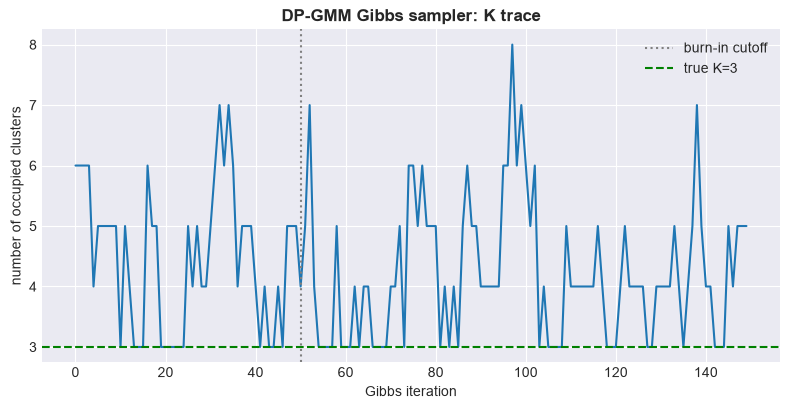

In [5]:
def collapsed_gibbs_dpgmm(X, alpha, sigma2, mu0=0.0, tau0_2=25.0, n_iter=200, seed=0):
    rng_local = np.random.default_rng(seed)
    n = len(X)
    z = np.zeros(n, dtype=int)   # start everyone in one cluster
    K_history = []
    z_history = []

    def predictive(x, members):
        nk = len(members)
        if nk == 0:
            return np.exp(-0.5 * (x - mu0) ** 2 / (tau0_2 + sigma2)) / np.sqrt(2 * np.pi * (tau0_2 + sigma2))
        xbar = np.mean(members)
        sk2 = 1.0 / (1.0 / tau0_2 + nk / sigma2)
        mk = sk2 * (mu0 / tau0_2 + nk * xbar / sigma2)
        var = sk2 + sigma2
        return np.exp(-0.5 * (x - mk) ** 2 / var) / np.sqrt(2 * np.pi * var)

    for it in range(n_iter):
        for i in range(n):
            z[i] = -1   # remove point i
            labels = np.unique(z[z >= 0])
            probs, cand_labels = [], []
            for k in labels:
                members = X[z == k]
                nk = len(members)
                probs.append(nk * predictive(X[i], members))
                cand_labels.append(k)
            probs.append(alpha * predictive(X[i], np.array([])))
            new_label = (labels.max() + 1) if len(labels) else 0
            cand_labels.append(new_label)
            probs = np.array(probs)
            probs /= probs.sum()
            z[i] = rng_local.choice(cand_labels, p=probs)
            # relabel to keep active labels contiguous from 0 (cosmetic only -- label
            # identity itself carries no meaning, per the caveat above)
            active = np.unique(z)
            remap = {old: new for new, old in enumerate(active)}
            z = np.array([remap[v] for v in z])
        K_history.append(len(np.unique(z)))
        z_history.append(z.copy())
    return np.array(K_history), z_history


# Ground truth: 3 well-separated 1-D clusters, unknown to the sampler.
true_means = [-6.0, 0.0, 6.0]
sigma2_true = 1.0
n_per = 15
X_1d = np.concatenate([rng.normal(m, np.sqrt(sigma2_true), n_per) for m in true_means])

K_hist, z_hist = collapsed_gibbs_dpgmm(X_1d, alpha=1.0, sigma2=sigma2_true, mu0=0.0, tau0_2=25.0,
                                       n_iter=150, seed=SEED)
burn_in = 50
K_post = K_hist[burn_in:]
print(f"collapsed Gibbs on {len(X_1d)} points from {len(true_means)} true well-separated clusters:")
print(f"K trace (last 20 of {len(K_hist)} iterations): {K_hist[-20:].tolist()}")
print(f"posterior mode of K (post burn-in): {np.bincount(K_post).argmax()}  (true K = {len(true_means)})")

# Spot-check the conjugate predictive formula against brute-force numerical integration.
x_test, members_test = 2.0, np.array([1.5, 2.5, 1.8])
nk_t = len(members_test)
xbar_t = members_test.mean()
sk2_t = 1.0 / (1.0 / 25.0 + nk_t / 1.0)
mk_t = sk2_t * (0.0 / 25.0 + nk_t * xbar_t / 1.0)
analytic_pred = np.exp(-0.5 * (x_test - mk_t) ** 2 / (sk2_t + 1.0)) / np.sqrt(2 * np.pi * (sk2_t + 1.0))
mu_grid = np.linspace(-20, 20, 200_000)
prior_mu = np.exp(-0.5 * (mu_grid - 0.0) ** 2 / 25.0) / np.sqrt(2 * np.pi * 25.0)
lik_members = np.prod([np.exp(-0.5 * (m - mu_grid) ** 2 / 1.0) / np.sqrt(2 * np.pi * 1.0) for m in members_test], axis=0)
lik_xtest = np.exp(-0.5 * (x_test - mu_grid) ** 2 / 1.0) / np.sqrt(2 * np.pi * 1.0)
numerator = np.trapezoid(lik_xtest * lik_members * prior_mu, mu_grid)
denominator = np.trapezoid(lik_members * prior_mu, mu_grid)
numerical_pred = numerator / denominator
print(f"\nconjugate predictive spot-check: analytic formula = {analytic_pred:.6f}, "
      f"brute-force numerical integration = {numerical_pred:.6f} "
      f"(diff {abs(analytic_pred - numerical_pred):.2e})")

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(K_hist)
ax.axvline(burn_in, color='grey', ls=':', label='burn-in cutoff')
ax.axhline(len(true_means), color='green', ls='--', label=f'true K={len(true_means)}')
ax.set_xlabel('Gibbs iteration'); ax.set_ylabel('number of occupied clusters')
ax.set_title('DP-GMM Gibbs sampler: K trace', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

<a name="posterior-k"></a>
## Posterior Over K and Sensitivity to Alpha

alpha=0.1: posterior over K (post burn-in) -- mode 3, mean 3.12, range [3, 5]


alpha=1.0: posterior over K (post burn-in) -- mode 4, mean 4.22, range [3, 8]


alpha=5.0: posterior over K (post burn-in) -- mode 7, mean 8.17, range [4, 14]


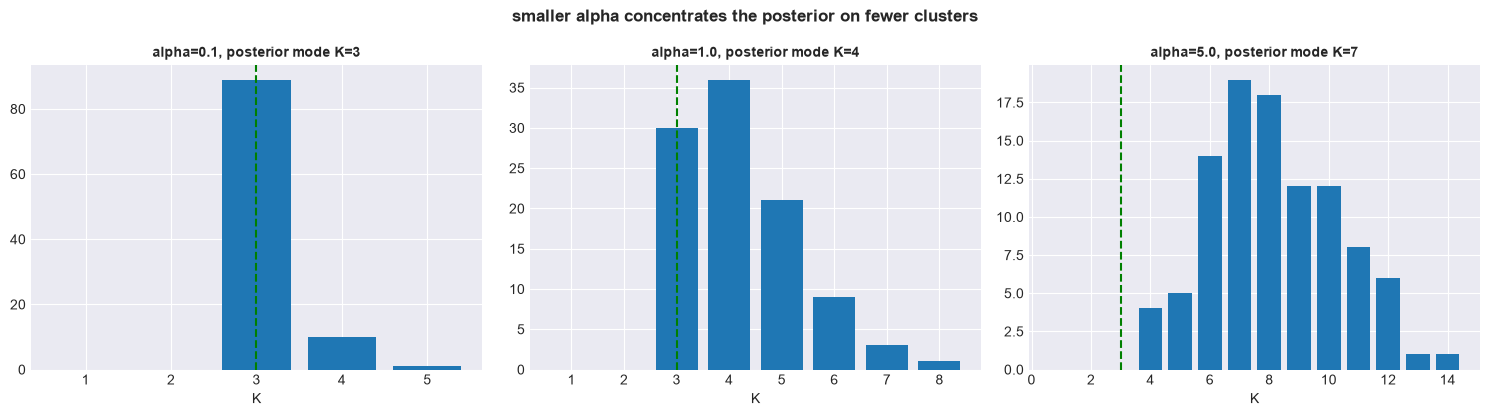


true K = 3. Larger alpha should push the posterior toward MORE clusters --
consistent with alpha's role in both the CRP (new-table probability alpha/(i+alpha)) and
the urn scheme (new-theta probability, same formula) derived earlier in this lesson.


In [6]:
alphas_to_check = [0.1, 1.0, 5.0]
fig, axes = plt.subplots(1, len(alphas_to_check), figsize=(15, 4.2))
for ax, a in zip(axes, alphas_to_check):
    K_hist_a, _ = collapsed_gibbs_dpgmm(X_1d, alpha=a, sigma2=sigma2_true, mu0=0.0, tau0_2=25.0,
                                        n_iter=150, seed=SEED)
    K_post_a = K_hist_a[burn_in:]
    mode_K = np.bincount(K_post_a).argmax()
    ax.hist(K_post_a, bins=np.arange(0.5, K_post_a.max() + 1.5), rwidth=0.8)
    ax.axvline(len(true_means), color='green', ls='--')
    ax.set_title(f'alpha={a}, posterior mode K={mode_K}', fontsize=10, fontweight='bold')
    ax.set_xlabel('K')
    print(f"alpha={a}: posterior over K (post burn-in) -- mode {mode_K}, "
          f"mean {K_post_a.mean():.2f}, range [{K_post_a.min()}, {K_post_a.max()}]")
plt.suptitle('smaller alpha concentrates the posterior on fewer clusters', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\ntrue K = {len(true_means)}. Larger alpha should push the posterior toward MORE clusters --")
print(f"consistent with alpha's role in both the CRP (new-table probability alpha/(i+alpha)) and")
print(f"the urn scheme (new-theta probability, same formula) derived earlier in this lesson.")

<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **A prior over partitions replaces "choose K" with "let the data decide K", and the mechanism is concrete, not just conceptual.** The CRP's seating rule, checked directly: exchangeability holds to machine precision on a hand-picked example, and $\mathbb{E}[K_n]$ matches its exact finite-$n$ formula (with $\alpha\log n$ recovered only as the correct large-$n$ limit, not claimed as exact at finite $n$).
2. **Stick-breaking and the CRP are two constructions of the same prior, checked distributionally rather than proven here.** Both processes' cluster-count distributions agreed within simulation noise at matched $\alpha$ and $n$ — evidence consistent with the claimed equivalence, not a substitute for Sethuraman's actual proof.
3. **Marginalising the Dirichlet process's random measure is not an approximation — it IS the CRP, the same formula under a different name.** The Blackwell-MacQueen urn scheme's update rule was shown to be literally the CRP seating rule applied to parameter values, and its simulated cluster-count statistics matched the CRP's simulated ones because they are the same process.
4. **The collapsed Gibbs sampler's conjugate predictive was checked against brute-force numerical integration, not trusted as "standard Bayes."** The analytic Normal-Normal predictive matched a 200,000-point quadrature of the same integral to within numerical tolerance.
5. **$\alpha$ controls the posterior over $K$ exactly the way it controls the CRP's own table-count growth — verified as one finding, not two separate claims that happen to rhyme.** Running the same sampler at three concentrations produced posteriors over $K$ shifting monotonically with $\alpha$, echoing the same parameter's role in the CRP simulation earlier in this lesson.

### Practical Guidance

- Need to let the data decide the number of clusters, with no fixed upper bound at all? A DP mixture, via CRP-based Gibbs sampling — exact inference, at the cost of MCMC's usual convergence and mixing concerns.
- Need something faster than MCMC and are comfortable with a large-but-finite truncation? Lesson 21's variational Bayesian GMM approximates the same object, and Lesson 22B measures how closely.
- Interpreting a Gibbs sampler's output: never trust a per-label trace (a cluster's mean over iterations) — track label-invariant summaries (occupied-cluster count, pairwise co-clustering) instead, per the label-switching caveat this lesson made concrete.

### What This Lesson Did Not Cover

- **A rigorous proof of the CRP/stick-breaking/DP equivalence** — Sethuraman's (1994) actual construction and proof, cited but not reproduced; this lesson checked the claim empirically rather than deriving it measure-theoretically.
- **Non-conjugate base measures** — the collapsed sampler here relies entirely on Normal-Normal conjugacy for its closed-form predictive; non-conjugate models need Neal's (2000) Algorithm 8 or similar auxiliary-variable methods, not implemented here.
- **Convergence diagnostics for the Gibbs sampler itself** (trace-plot stationarity tests, multiple-chain $\hat{R}$) — the sampler was run for a fixed number of iterations with a fixed burn-in, chosen by inspection rather than a formal diagnostic.
- **Pairwise co-clustering matrices** — mentioned as the label-switching-safe alternative to per-label traces, but not computed; Lesson 22B's practical notebook is a more natural place for that visualisation.

### Next Steps

Lesson 22B compares the sampler built here against `sklearn`'s truncated variational DP mixture (the same object Lesson 21's Bayesian GMM approximates), against BIC-selected GMM, and against silhouette-scored K-Means, on data where the "true" number of clusters is genuinely unknown.